## Feature Set Extraction

#### i.e. Scenario 3 (n=25), Scenario 4 (n=14), Scenario 5 (n=6)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
essays = pd.read_csv("tables\paper_table_new_essays.csv")
fiction = pd.read_csv("tables\paper_table_new_fiction.csv")
news = pd.read_csv("tables\paper_table_new_news.csv")

TOP_K = 15

# -------- Function to get ordered top-k --------
def get_topk(df, k):
    df_sorted = df.reindex(df["cohens_d"].abs().sort_values(ascending=False).index)
    return df_sorted[["metric", "cohens_d"]].head(k).reset_index(drop=True)

# -------- Get top-k per genre --------
top_essays = get_topk(essays, TOP_K)
top_fiction = get_topk(fiction, TOP_K)
top_news = get_topk(news, TOP_K)


# -------- Combine into one table --------
combined = pd.DataFrame({
    "Rank": range(1, TOP_K + 1),

    "Essays_Feature": top_essays["metric"],
    "Essays_d": top_essays["cohens_d"],

    "Fiction_Feature": top_fiction["metric"],
    "Fiction_d": top_fiction["cohens_d"],

    "News_Feature": top_news["metric"],
    "News_d": top_news["cohens_d"],
})

# -------- Display --------
print(combined)

# Convert to sets of feature names
set_essays = set(top_essays["metric"])
set_fiction = set(top_fiction["metric"])
set_news = set(top_news["metric"])

# Intersection (common in ALL)
common_all = set_essays & set_fiction & set_news

# Union (appearing in ANY)
common_any = set_essays | set_fiction | set_news

print("Common in ALL genres:\n", common_all)
print("\nAppearing in ANY:\n", common_any)

    Rank                        Essays_Feature  Essays_d  \
0      1         m15_jensen_shannon_divergence -2.092044   
1      2               m01_average_word_length -1.692274   
2      3                             m34_mattr -1.534884   
3      4                   m05_lexical_density -1.495066   
4      5               m27_flesch_reading_ease  1.471135   
5      6  m39_sentence_construction_uniformity -1.424921   
6      7               m07_sentence_length_std  1.250990   
7      8                 m36_zipfian_r_squared  1.208396   
8      9                     m36_zipfian_alpha  1.200190   
9     10                  m02_type_token_ratio -1.177278   
10    11                    m04_hapax_legomena -1.160810   
11    12                 m28_gunning_fog_index -1.140822   
12    13                      m16_pos_bigram_0 -1.138158   
13    14                         m35_honores_r -1.081602   
14    15              m26_flesch_kincaid_grade -1.076203   

                         Fiction_Featur

In [6]:
# -------- Individual only --------
only_essays = set_essays - set_fiction - set_news
only_fiction = set_fiction - set_essays - set_news
only_news = set_news - set_essays - set_fiction

# -------- Pairwise intersections (excluding the 3-way overlap) --------
essays_fiction = (set_essays & set_fiction) - set_news
essays_news = (set_essays & set_news) - set_fiction
fiction_news = (set_fiction & set_news) - set_essays

# -------- All three --------
all_three = set_essays & set_fiction & set_news

def print_set(name, s):
    print(f"\n{name} ({len(s)}):")
    for item in sorted(s):
        print("-", item)

print_set("Only Essays", only_essays)
print_set("Only Fiction", only_fiction)
print_set("Only News", only_news)

print_set("Essays ∩ Fiction", essays_fiction)
print_set("Essays ∩ News", essays_news)
print_set("Fiction ∩ News", fiction_news)

print_set("All Three (Essays ∩ Fiction ∩ News)", all_three)


Only Essays (2):
- m16_pos_bigram_0
- m34_mattr

Only Fiction (3):
- m10_punct_,
- m10_punct_;
- m11_punctuation_consistency

Only News (6):
- m03_yules_k
- m14_cosine_similarity
- m20_word_bigram_entropy
- m23_perplexity_approximation
- m24_shannon_entropy
- m25_cross_entropy_loss

Essays ∩ Fiction (5):
- m02_type_token_ratio
- m04_hapax_legomena
- m05_lexical_density
- m07_sentence_length_std
- m35_honores_r

Essays ∩ News (2):
- m26_flesch_kincaid_grade
- m28_gunning_fog_index

Fiction ∩ News (1):
- m40_token_predictability_variance

All Three (Essays ∩ Fiction ∩ News) (6):
- m01_average_word_length
- m15_jensen_shannon_divergence
- m27_flesch_reading_ease
- m36_zipfian_alpha
- m36_zipfian_r_squared
- m39_sentence_construction_uniformity


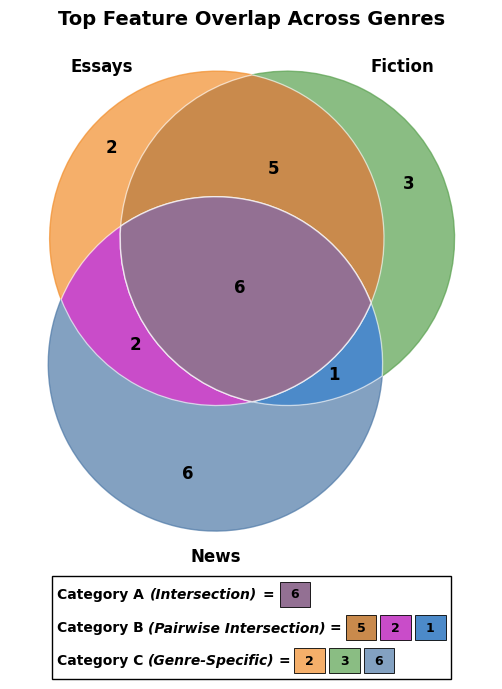

In [7]:
from matplotlib_venn import venn3
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, VPacker, TextArea, DrawingArea

# Same color palette as before
VENN_COLORS = {
    "Essays": "#F28E2B",
    "Fiction": "#59A14F",
    "News": "#4E79A7"
}

plt.figure(figsize=(9,7))

v = venn3(
    [set_essays, set_fiction, set_news],
    set_labels=("Essays", "Fiction", "News")
)

# -------------------------------
# Style circles
# -------------------------------
for pid in ['100', '010', '001', '110', '101', '011', '111']:
    patch = v.get_patch_by_id(pid)
    if patch:
        patch.set_alpha(0.7)
        patch.set_edgecolor('white')

# Base colors
v.get_patch_by_id('100').set_color(VENN_COLORS["Essays"])
v.get_patch_by_id('010').set_color(VENN_COLORS["Fiction"])
v.get_patch_by_id('001').set_color(VENN_COLORS["News"])

# Labels
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for text in v.subset_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

plt.title("Top Feature Overlap Across Genres", fontsize=14, weight='bold')


# -------------------------------
# Helper: colored numbered box
# -------------------------------
def number_box(color, number):
    da = DrawingArea(22, 18, 0, 0)
    rect = Rectangle((0, 0), 22, 18, fc=color, ec='black', lw=0.6)
    da.add_artist(rect)

    txt = plt.Text(
        x=11, y=9,
        text=str(number),
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='black'
    )
    da.add_artist(txt)
    return da


# -------------------------------
# Build legend rows
# -------------------------------

# Colors from actual venn sections
c111 = v.get_patch_by_id('111').get_facecolor()
c110 = v.get_patch_by_id('110').get_facecolor()
c101 = v.get_patch_by_id('101').get_facecolor()
c011 = v.get_patch_by_id('011').get_facecolor()
c100 = v.get_patch_by_id('100').get_facecolor()
c010 = v.get_patch_by_id('010').get_facecolor()
c001 = v.get_patch_by_id('001').get_facecolor()

# Row 1: 6 = genre invariant
row1 = HPacker(children=[
    TextArea("Category A", textprops=dict(size=10, weight='bold')),
    TextArea("(Intersection)", textprops=dict(size=10, weight="bold", style='italic')),
    TextArea("=", textprops=dict(size=10, weight='bold')),
    number_box(c111, 6)    
], align="center", pad=0, sep=4)

# Row 2: 5 + 2 + 1 + 6 = cross-genre
row2 = HPacker(children=[
    TextArea("Category B", textprops=dict(size=10, weight='bold')),
    TextArea("(Pairwise Intersection)", textprops=dict(size=10, weight="bold", style='italic')),
    TextArea("=", textprops=dict(size=10, weight='bold')),
    number_box(c110, 5),
    # TextArea(",", textprops=dict(size=10, weight='bold')),
    number_box(c101, 2),
    # TextArea(",", textprops=dict(size=10, weight='bold')),
    number_box(c011, 1)
], align="center", pad=0, sep=3)

# Row 3: all regions
row3 = HPacker(children=[
    TextArea("Category C", textprops=dict(size=10, weight='bold')),
    TextArea("(Genre-Specific)", textprops=dict(size=10, weight="bold", style='italic')),
    TextArea("=", textprops=dict(size=10, weight='bold')),
    number_box(c100, 2),
    # TextArea(",", textprops=dict(size=10, weight='bold')),
    number_box(c010, 3),
    # TextArea(",", textprops=dict(size=10, weight='bold')),
    number_box(c001, 6)
], align="center", pad=0, sep=3)

legend_box = VPacker(children=[row1, row2, row3], align="left", pad=0, sep=6)

anchored_box = AnchoredOffsetbox(
    loc='lower center',
    child=legend_box,
    pad=0.4,
    frameon=True,
    bbox_to_anchor=(0.5, -0.22),
    bbox_transform=plt.gca().transAxes,
    borderpad=0.6
)

plt.gca().add_artist(anchored_box)

plt.tight_layout()
plt.show()

## Scenario Wise Change in Performance Frontier Graphs

C:\Users\Dell\AppData\Local\Temp\ipykernel_15460\2437803184.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


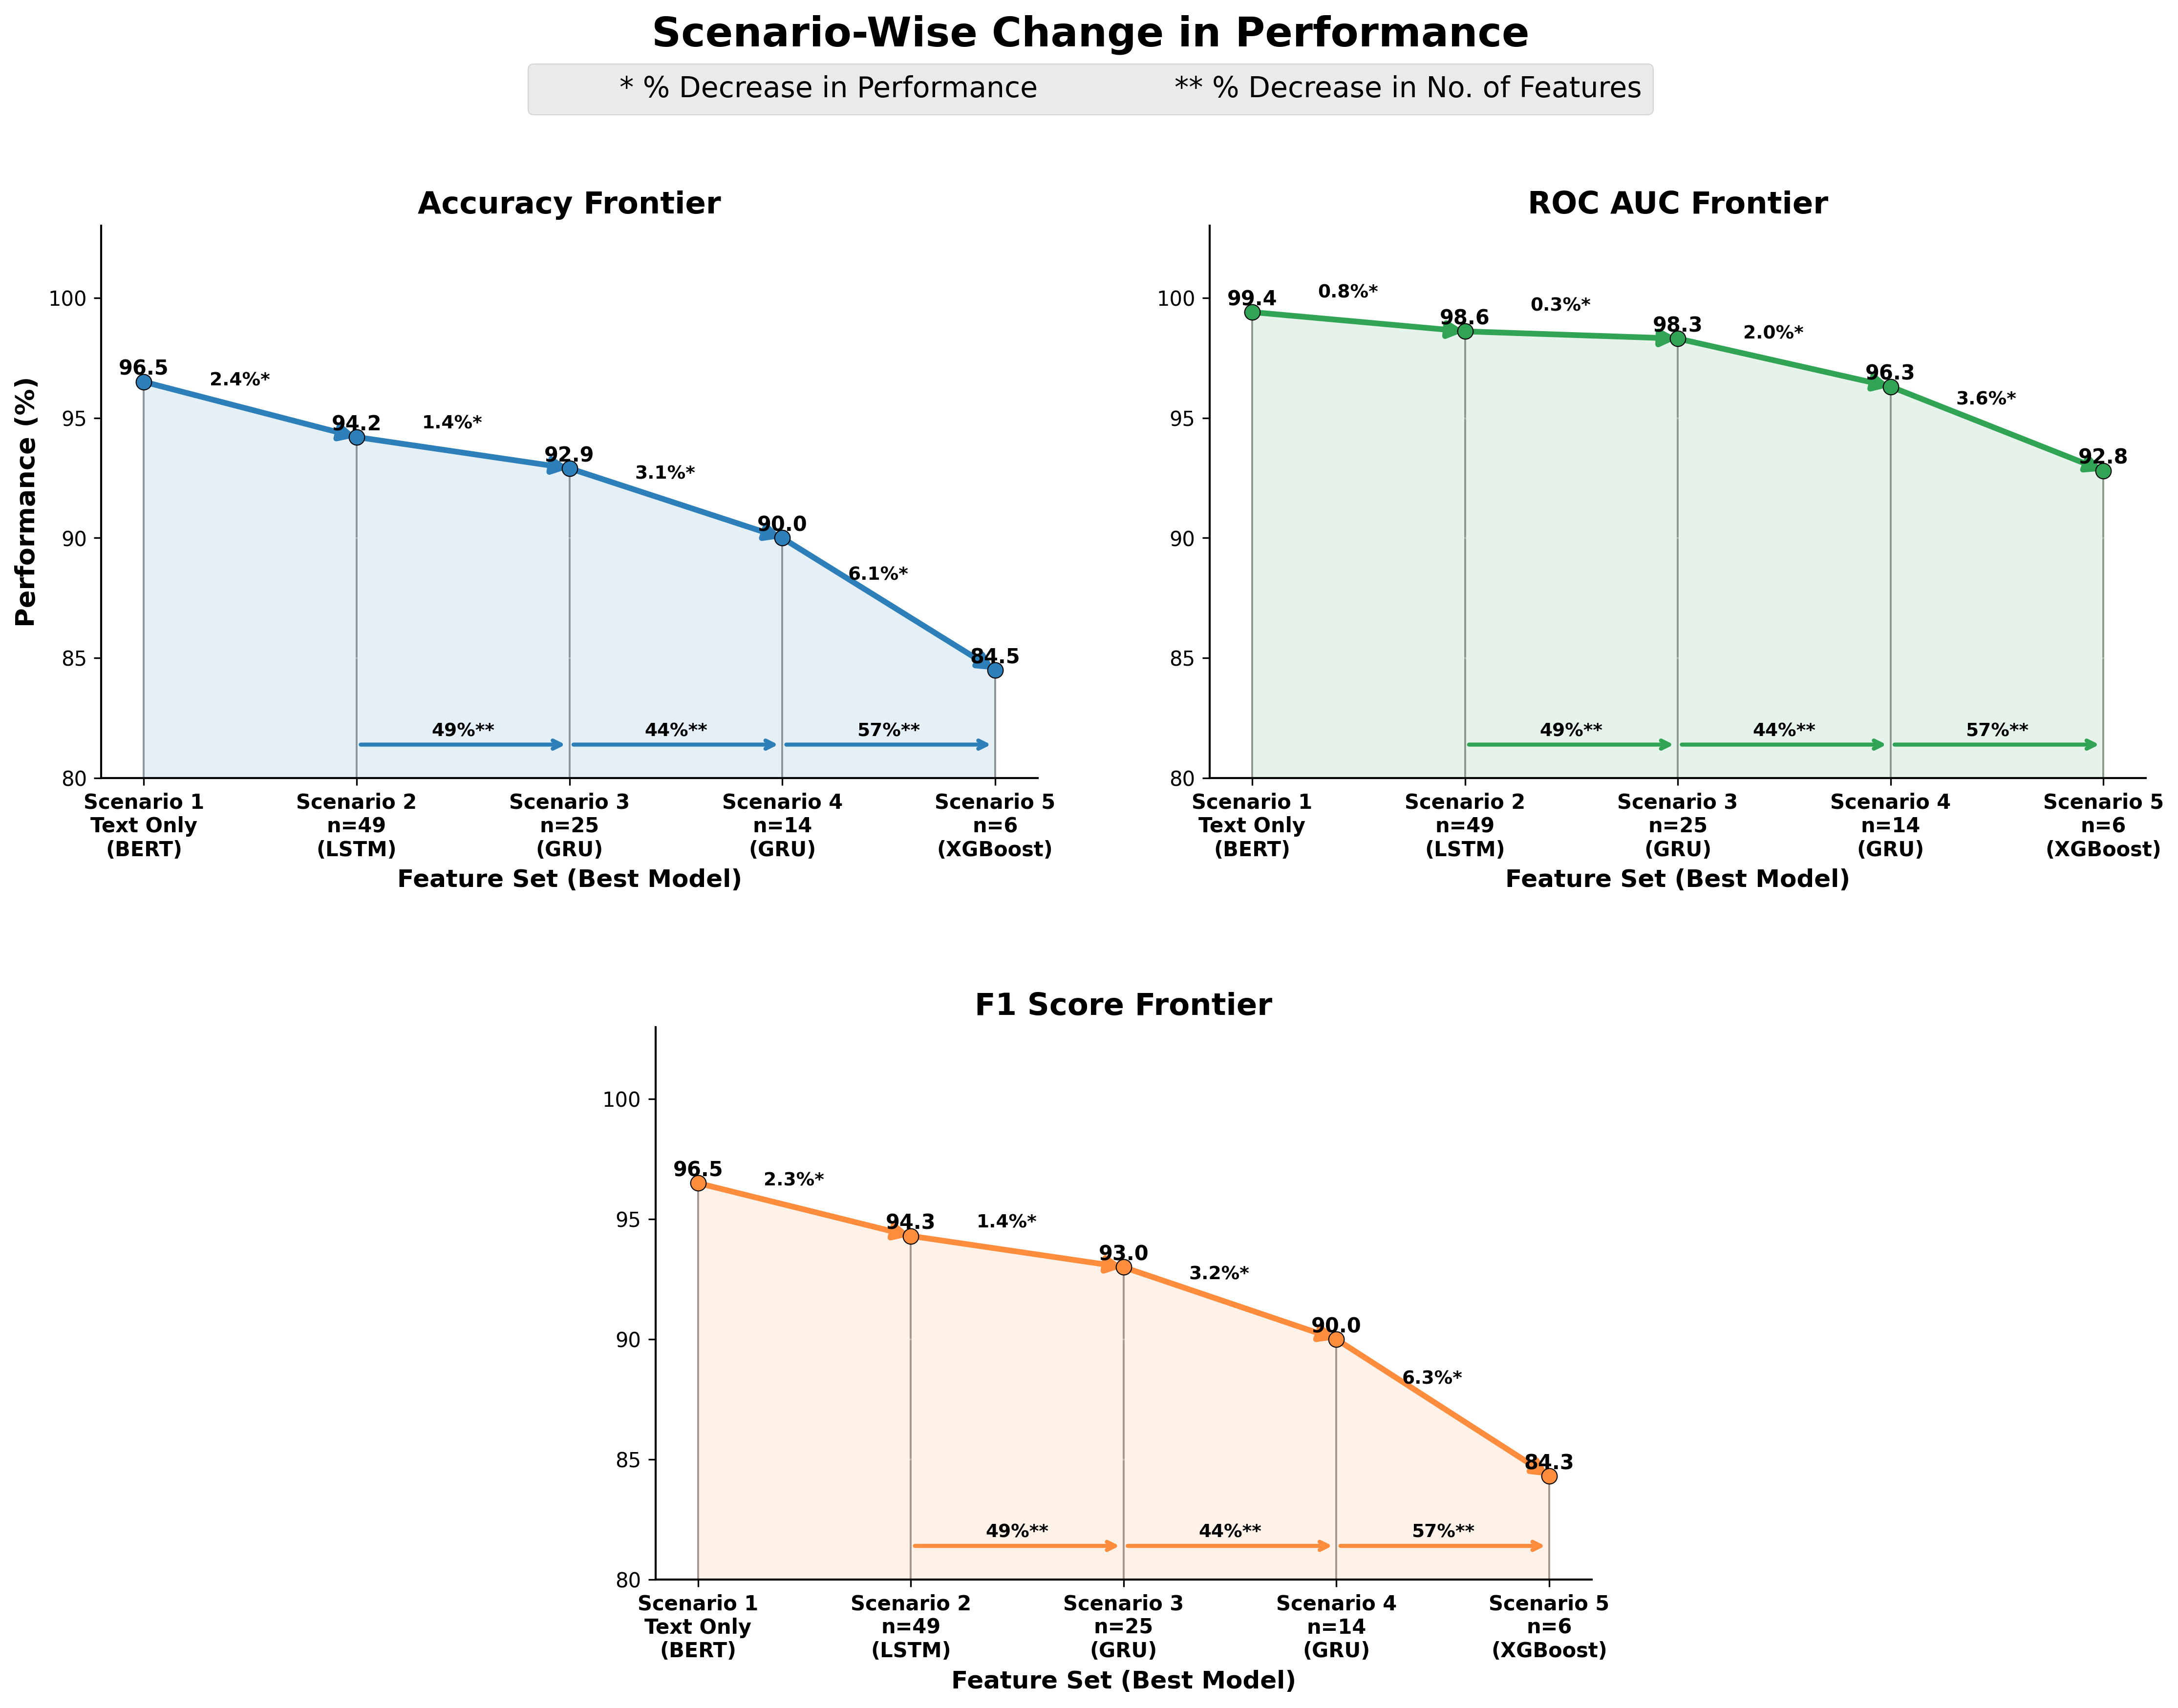

In [8]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# -------------------------------------------------
# DATA
# -------------------------------------------------
x_labels = [
    "Scenario 1\nText Only\n(BERT)",
    "Scenario 2\nn=49\n(LSTM)",
    "Scenario 3\nn=25\n(GRU)",
    "Scenario 4\nn=14\n(GRU)",
    "Scenario 5\nn=6\n(XGBoost)"
]

x = np.arange(len(x_labels))

# reversed values
accuracy = np.array([96.5, 94.2, 92.9, 90.0, 84.5])
roc_auc  = np.array([99.4, 98.6, 98.3, 96.3, 92.8])
f1_score = np.array([96.5, 94.3, 93.0, 90.0, 84.3])

features = [None, 49, 25, 14, 6]

# -------------------------------------------------
# HELPERS
# -------------------------------------------------
def pct_change(arr):
    vals = [None]
    for i in range(1, len(arr)):
        vals.append(((arr[i-1] - arr[i]) / arr[i-1]) * 100)
    return vals

# metric change
acc_gain = pct_change(accuracy)
roc_gain = pct_change(roc_auc)
f1_gain  = pct_change(f1_score)

# feature reduction %
feat_drop = [None, None]
for i in range(2, len(features)):
    prev = features[i-1]
    curr = features[i]
    drop = ((prev - curr) / prev) * 100
    feat_drop.append(drop)

# -------------------------------------------------
# STYLE
# -------------------------------------------------
plt.style.use("ggplot")

fig = plt.figure(figsize=(18, 12), dpi=300)
gs = gridspec.GridSpec(
    2, 4,              # 2 rows, 4 columns
    figure=fig,
    wspace=0.45,       # horizontal spacing
    hspace=0.45        # vertical spacing
)

# Same-size axes
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left
ax2 = fig.add_subplot(gs[0, 2:4])   # top-right
ax3 = fig.add_subplot(gs[1, 1:3])   # bottom-center

axes = [ax1, ax2, ax3]
fig.patch.set_facecolor("white")

titles = ["Accuracy Frontier", "ROC AUC Frontier", "F1 Score Frontier"]
series = [accuracy, roc_auc, f1_score]
metric_gains = [acc_gain, roc_gain, f1_gain]
colors = ["#2C7FB8", "#31A354", "#FD8D3C"]

# -------------------------------------------------
# LOOP
# -------------------------------------------------
for ax, y, mgain, title, color in zip(axes, series, metric_gains, titles, colors):

    ax.set_facecolor("white")

    # ---------------------------------------------
    # ARROWED MAIN LINE
    # ---------------------------------------------
    for i in range(len(x)-1):
        ax.annotate(
            "",
            xy=(x[i+1], y[i+1]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=2.8,
                mutation_scale=16,
                shrinkA=0,
                shrinkB=0
            ),
            zorder=3
        )

    ax.scatter(
        x, y,
        s=58,
        color=color,
        edgecolor="black",
        zorder=4
    )

    ax.fill_between(x, y, 80, color=color, alpha=0.12)

    # vertical guides stop at plotted point
    y_base = 80   # same as chart lower limit

    for xi, yi in zip(x, y):
        ax.vlines(
            x=xi,
            ymin=y_base,
            ymax=yi,
            linestyle="-",
            linewidth=0.9,
            color="black",
            alpha=0.45,
            zorder=0
        )

    # point labels
    for xi, yi in zip(x, y):
        ax.text(
            xi, yi + 0.28,
            f"{yi:.1f}",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color="black"
        )

    # ---------------------------------------------
    # TEXT + FEATURE ARROWS
    # ---------------------------------------------
    for i in range(1, len(x)):

        mid_x = (x[i] + x[i-1]) / 2
        mid_y = (y[i] + y[i-1]) / 2

        # * Accuracy %
        ax.text(
            mid_x - 0.05,
            mid_y + 1.0,
            f"{mgain[i]:.1f}%*",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#000000"
        )

        # ** Feature %
        if feat_drop[i] is not None:

            y_arrow = 81.4   # all arrows one straight line near x-axis

            ax.annotate(
                "",
                xy=(x[i], y_arrow),
                xytext=(x[i-1], y_arrow),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0
                )
            )

            ax.text(
                mid_x,
                y_arrow + 0.35,
                f"{feat_drop[i]:.0f}%**",
                ha="center",
                fontsize=9,
                fontweight="bold",
                color="#000000"
            )

    # ---------------------------------------------
    # FORMATTING
    # ---------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(
        x_labels,
        fontsize=10,
        fontweight="bold",
        color="black"
    )

    ax.set_ylim(80, 103)
    ax.set_yticks(np.arange(80, 101, 5))

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color="black"
    )

    ax.set_xlabel(
        "Feature Set (Best Model)",
        fontsize=12,
        fontweight="bold",
        color="black"
    )

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.grid(axis='x', alpha=0.10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(colors='black')

# left ylabel
axes[0].set_ylabel(
    "Performance (%)",
    fontsize=13,
    fontweight="bold",
    color="black"
)

# -------------------------------------------------
# GLOBAL LEGEND
# -------------------------------------------------
legend_elements = [
    Line2D([0], [0], color='none', label='* % Decrease in Performance'),
    Line2D([0], [0], color='none', label='** % Decrease in No. of Features')
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=True,
    fontsize=14
)

# title
fig.suptitle(
    "Scenario-Wise Change in Performance",
    fontsize=20,
    fontweight="bold",
    color="black",
    y=1
)

plt.tight_layout()
plt.savefig(
    "scenario_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()